# Supplementary Figure S4(A) — Base-pair score ECDFs by dataset quality

Cumulative score distributions for curated, all, and lower-quality datasets.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_ROOT = Path.cwd().parent.parent
FIGURES = _ROOT / "figures"

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / name

In [2]:
LW = ["cWW", "tWW", "cWH", "tWH", "cWS", "tWS", "cHH", "tHH", "cHS", "tHS", "cSS", "tSS"]


CUT = 75


GOOD_C, ALL_C, POOR_C = "#2ca02c", "#1f77b4", "#d62728"


def scored_pairs(lw_only=True):
    """Unambiguous, scored per-pair records. lw_only keeps the 12 canonical LW classes."""
    raw = pd.DataFrame(json.loads(l) for l in open(data_file("reference/scores/pair_scores_uniques_parse.jsonl")))
    df = raw[~raw["is_ambiguous"] & raw["score"].notna()].copy()
    if lw_only:
        df = df[df["lw_class"].isin(LW)].copy()
    return df


def good_poor_sets():
    good = set(json.load(open(data_file("reference/reference_sets/reference_set.json")))["pdbs"])
    poor = set(json.load(open(data_file("reference/reference_sets/reference_set_poor.json")))["pdbs"])
    return good, poor


def split_good_poor(df):
    """Return (df_good, df_poor) subsets by curated / lower-quality PDB membership."""
    good, poor = good_poor_sets()
    u = df["pdb_id"].str.upper()
    return df[u.isin(good)], df[u.isin(poor)]

saved figures/figS4_A_score_ecdf_by_quality.png


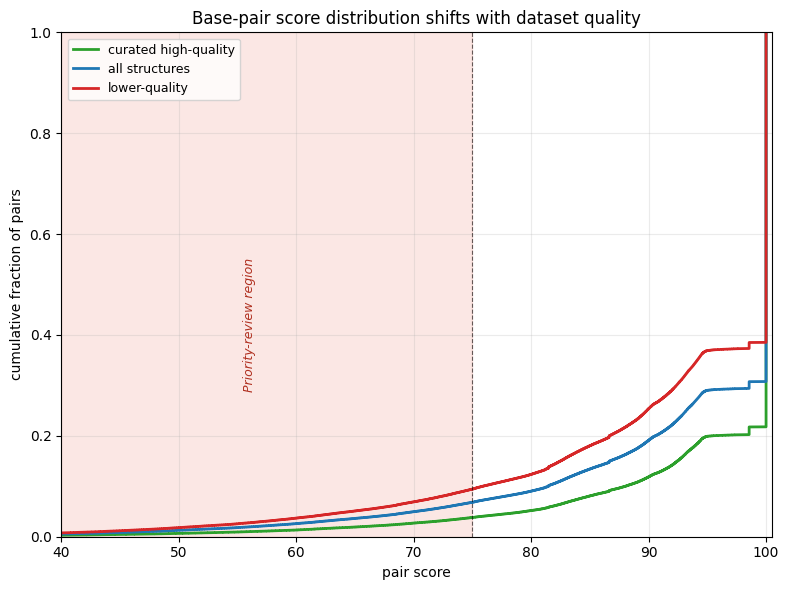

In [3]:
df = scored_pairs(lw_only=True)
df_good, df_poor = split_good_poor(df)
fig, ax = plt.subplots(figsize=(8, 6))
ax.axvspan(40, CUT, color='#e34a33', alpha=0.13, zorder=0)
ax.text(56, 0.42, 'Priority-review region', ha='center', va='center', rotation=90,
        fontsize=9, color='#b03020', style='italic')
for sub, lab, c in [(df_good, 'curated high-quality', GOOD_C),
                    (df, 'all structures', ALL_C),
                    (df_poor, 'lower-quality', POOR_C)]:
    s = np.sort(sub['score'].values)
    ax.plot(s, np.arange(1, len(s)+1)/len(s), label=lab, color=c, lw=2.0)
ax.axvline(CUT, color='k', ls='--', lw=0.8, alpha=0.6)
ax.set_xlim(40, 100.5); ax.set_ylim(0, 1)
ax.set_xlabel('pair score'); ax.set_ylabel('cumulative fraction of pairs')
ax.set_title('Base-pair score distribution shifts with dataset quality')
ax.legend(fontsize=9, loc='upper left'); ax.grid(alpha=0.25)
fig.tight_layout(); print('saved', savefig(fig, 'figS4_A_score_ecdf_by_quality.png')); plt.show()